# Molecular Representations and RDKit

## Learning Objectives

By the end of this notebook you will be able to:

- Read and write **SMILES strings** for organic molecules.
- Use **RDKit** to parse molecular structures, compute properties, and draw molecules.
- Understand and compute **molecular descriptors** (MW, LogP, TPSA, HBD, HBA).
- Generate and compare **Morgan fingerprints** using **Tanimoto similarity**.
- Perform basic **molecular editing** (atom replacement, functional group modification).
- Work with molecular data in **pandas DataFrames** to build analysis-ready datasets.

## Prerequisites

- Basic Python and pandas knowledge (Module 00).
- No prior chemistry background is assumed — all concepts are introduced from scratch.

## Setup

In [2]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system("pip install -q rdkit-pypi scikit-learn")

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, Crippen, rdMolDescriptors, AllChem
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import (
    apply_style,
    PALETTE,
    SALMON,
    EMERALD,
    PERIWINKLE,
    CYAN,
    ORCHID,
    GOLD,
)

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  ✓ media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)

---

## 1. SMILES — A Text Language for Molecules

Before we can apply any statistical or machine-learning method to molecular data, we need a way to represent molecules in a form that a computer can read, store, and manipulate. The most widely used format is **SMILES** (Simplified Molecular-Input Line-Entry System).

A SMILES string encodes the molecular graph — atoms as nodes and bonds as edges — into a compact ASCII string. The key advantage is that a single line of text can fully specify a complex three-dimensional molecule, making it easy to store millions of compounds in a database or pass them to software tools.

### 1.1 Atoms

The **organic subset** of atoms can be written without brackets: **B, C, N, O, P, S, F, Cl, Br, I**. For these atoms, hydrogen atoms are *implicit* — SMILES assumes each atom has enough hydrogens to fill its standard valence.

For example:
- `C` represents methane (CH$_4$) — carbon has valence 4, so 4 implicit hydrogens.
- `O` represents water (H$_2$O) — oxygen has valence 2, so 2 implicit hydrogens.
- `N` represents ammonia (NH$_3$) — nitrogen has valence 3, so 3 implicit hydrogens.

Square brackets `[ ]` are used when an atom has a formal charge, an unusual isotope, or a non-standard number of hydrogens. For instance, `[NH4+]` is the ammonium ion.

### 1.2 Bonds

|  Symbol  |  Bond type  | Example                   |
|:--------:|:-----------:|:--------------------------|
| *(none)* | Single bond | `CC` = ethane             |
|   `=`    | Double bond | `C=O` = formaldehyde      |
|   `#`    | Triple bond | `C#N` = hydrogen cyanide  |
|   `:`    |  Aromatic   | rarely written explicitly |

Single bonds between atoms are implied by adjacency — simply writing two atoms next to each other creates a single bond.

### 1.3 Branches

Parentheses denote **branches** (side chains) off a main chain. Everything inside `( )` is a substituent on the preceding atom:

- `CC(=O)O` — acetic acid. The main chain is C–C–O. The `(=O)` is a double-bonded oxygen branching off the second carbon.
- `CC(C)C` — isobutane. Two methyl groups branch off the central carbon.

### 1.4 Rings

Ring closures are indicated by **matching digits** placed after atoms. The first occurrence of a digit opens a ring, and the second occurrence closes it by forming a bond back to the opening atom:

- `C1CCCCC1` — cyclohexane. The `1` after the first C and the `1` after the last C form a bond that closes the six-membered ring.
- `C1CC1` — cyclopropane.

For molecules with more than 9 rings, use `%10`, `%11`, etc.

### 1.5 Aromaticity

Aromatic atoms are written in **lowercase**: `c`, `n`, `o`, `s`. This tells the parser that these atoms participate in an aromatic ring with delocalised electrons:

- `c1ccccc1` — benzene (aromatic six-membered ring).
- `c1ccncc1` — pyridine (aromatic ring with one nitrogen).

Using uppercase (`C1=CC=CC=C1`) represents the same molecule via explicit alternating double bonds (the Kekulé form), but the lowercase aromatic notation is preferred because it is unambiguous.

### 1.6 Stereochemistry (brief mention)

SMILES can encode stereochemistry using:
- **`/` and `\`** around double bonds for *E/Z* (cis/trans) isomerism.
- **`@` and `@@`** at tetrahedral centres for *R/S* configuration.

For example, `C(/F)=C/Cl` specifies a particular geometric isomer. We will not dwell on stereochemistry in this notebook, but it is important to know that SMILES can capture it.

### 1.7 Example Molecules

The table below shows SMILES strings for several molecules we will use throughout this notebook:

| Molecule      | SMILES                                             | Description                   |
|:--------------|:---------------------------------------------------|:------------------------------|
| Methanol      | `CO`                                               | Simplest alcohol              |
| Acetic acid   | `CC(=O)O`                                          | Two-carbon carboxylic acid    |
| Cyclohexane   | `C1CCCCC1`                                         | Six-membered saturated ring   |
| Pyridine      | `c1ccncc1`                                         | Aromatic ring with nitrogen   |
| Naproxen      | `CC(C1=CC2=C(C=C1)C=C(C2)OC)C(=O)O`                | NSAID, anti-inflammatory drug |
| Metformin     | `CN(C)C(=N)NC(=N)N`                                | First-line diabetes treatment |
| Penicillin V  | `CC1(C(N2C(S1)C(C2=O)NC(=O)COC3=CC=CC=C3)C(=O)O)C` | Beta-lactam antibiotic        |
| Ciprofloxacin | `C1CC1N2C=C(C(=O)C3=CC(=C(C=C32)N4CCNCC4)F)C(=O)O` | Fluoroquinolone antibiotic    |

---

## 2. Parsing Molecules with RDKit

**RDKit** is the standard open-source cheminformatics toolkit. It can parse SMILES strings into rich molecule objects, compute properties, generate 2D depictions, and much more. In this section we learn the fundamental operations: parsing, canonicalisation, and drawing.

### 2.1 Parsing a SMILES string

The function `Chem.MolFromSmiles()` takes a SMILES string and returns an RDKit molecule object. If the SMILES is invalid, it returns `None` — always check for this in production code.

### 2.2 Canonical SMILES

The same molecule can be written as many different SMILES strings (just as a graph can be traversed in different orders). RDKit's `Chem.MolToSmiles()` produces a **canonical SMILES** — a unique, deterministic string for each molecule. This is essential for deduplication: if two SMILES strings produce the same canonical form, they represent the same molecule.

The cell below parses naproxen from its SMILES string, prints the canonical form, and renders a 2D depiction. RDKit automatically computes 2D coordinates for drawing.

Input SMILES:     CC(C1=CC2=C(C=C1)C=C(C2)OC)C(=O)O
Canonical SMILES: COC1=Cc2ccc(C(C)C(=O)O)cc2C1
Number of atoms (heavy): 16
Number of bonds:         17


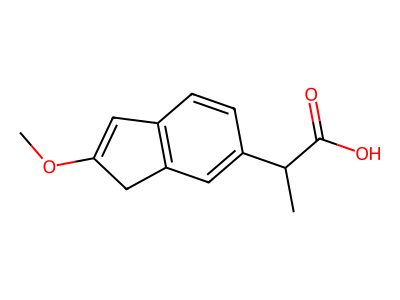

In [2]:
# Parse naproxen from SMILES
naproxen_smi = "CC(C1=CC2=C(C=C1)C=C(C2)OC)C(=O)O"
naproxen = Chem.MolFromSmiles(naproxen_smi)

print(f"Input SMILES:     {naproxen_smi}")
print(f"Canonical SMILES: {Chem.MolToSmiles(naproxen)}")
print(f"Number of atoms (heavy): {naproxen.GetNumAtoms()}")
print(f"Number of bonds:         {naproxen.GetNumBonds()}")

# Draw the molecule
Draw.MolToImage(naproxen, size=(400, 300))

### 2.3 Canonicalisation in action

To demonstrate that different SMILES strings for the same molecule yield the same canonical form, consider **paracetamol** (acetaminophen). We write three different valid SMILES by starting the traversal at different atoms:

In [ ]:
# Three different SMILES for paracetamol (acetaminophen)
smiles_variants = [
    "CC(=O)NC1=CC=C(O)C=C1",  # start from the acetyl group
    "OC1=CC=C(NC(C)=O)C=C1",  # start from the hydroxyl
    "c1cc(O)ccc1NC(=O)C",  # aromatic notation, start from ring
]

print("Input SMILES                          -> Canonical SMILES")
print("-" * 70)
canonical_forms = []
for smi in smiles_variants:
    mol = Chem.MolFromSmiles(smi)
    canon = Chem.MolToSmiles(mol)
    canonical_forms.append(canon)
    print(f"{smi:40s} -> {canon}")

print(f"\nAll canonical forms identical: {len(set(canonical_forms)) == 1}")

Input SMILES                          -> Canonical SMILES
----------------------------------------------------------------------
CC(=O)NC1=CC=C(O)C=C1                    -> CC(=O)Nc1ccc(O)cc1
OC1=CC=C(NC(C)=O)C=C1                    -> CC(=O)Nc1ccc(O)cc1
c1cc(O)ccc1NC(=O)C                       -> CC(=O)Nc1ccc(O)cc1

All canonical forms identical: True


### 2.4 Drawing a grid of molecules

RDKit's `Draw.MolsToGridImage()` renders multiple molecules side by side in a grid, which is useful for comparing structural features across a set of compounds. Below we draw six drug molecules that we will use as running examples throughout this notebook.

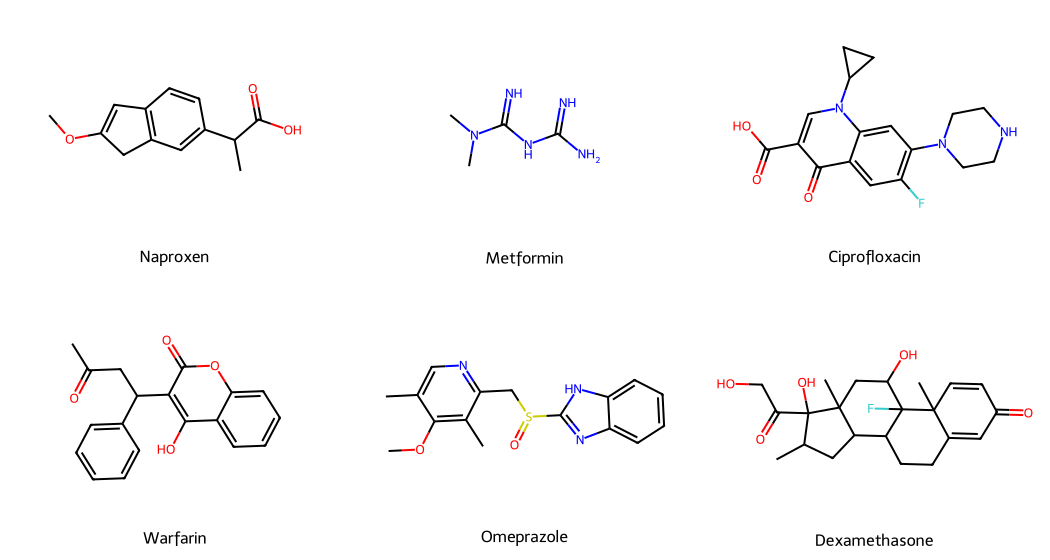

In [ ]:
# Define a panel of drug molecules
drug_smiles = {
    "Naproxen": "CC(C1=CC2=C(C=C1)C=C(C2)OC)C(=O)O",
    "Metformin": "CN(C)C(=N)NC(=N)N",
    "Ciprofloxacin": "C1CC1N2C=C(C(=O)C3=CC(=C(C=C32)N4CCNCC4)F)C(=O)O",
    "Warfarin": "CC(=O)CC(C1=CC=CC=C1)C2=C(C3=CC=CC=C3OC2=O)O",
    "Omeprazole": "CC1=CN=C(C(=C1OC)C)CS(=O)C2=NC3=CC=CC=C3N2",
    "Dexamethasone": "CC1CC2C3CCC4=CC(=O)C=CC4(C3(C(CC2(C1(C(=O)CO)O)C)O)F)C",
}

mols = [Chem.MolFromSmiles(smi) for smi in drug_smiles.values()]
names = list(drug_smiles.keys())

Draw.MolsToGridImage(mols, legends=names, molsPerRow=3, subImgSize=(350, 280))

### 2.5 Explicit vs. implicit hydrogens

By default, RDKit works with **implicit hydrogens** — hydrogen atoms are not stored as explicit nodes in the molecular graph, but their count is inferred from each heavy atom's valence. This keeps the data structure compact.

Sometimes we need **explicit hydrogens** (e.g., for 3D coordinate generation or certain descriptor calculations). `Chem.AddHs()` adds them; `Chem.RemoveHs()` strips them back.

In [ ]:
# Metformin: implicit vs explicit hydrogens
metformin = Chem.MolFromSmiles("CN(C)C(=N)NC(=N)N")
metformin_h = Chem.AddHs(metformin)

print(f"Metformin (implicit H): {metformin.GetNumAtoms()} atoms")
print(f"Metformin (explicit H): {metformin_h.GetNumAtoms()} atoms")
print(
    f"Difference = {metformin_h.GetNumAtoms() - metformin.GetNumAtoms()} hydrogen atoms"
)

Metformin (implicit H): 9 atoms
Metformin (explicit H): 20 atoms
Difference = 11 hydrogen atoms


---

## 3. Molecular Descriptors

A **molecular descriptor** is a numerical value that encodes some structural, physical, or chemical property of a molecule. Descriptors are the bridge between the qualitative world of molecular structures and the quantitative world of statistical modelling — they turn molecules into feature vectors that regression models, classifiers, and other algorithms can consume.

### 3.1 Key descriptors

We focus on six widely used descriptors:

**Molecular Weight (MW).** The sum of the atomic masses of all atoms in the molecule (including implicit hydrogens). Larger molecules tend to have lower oral absorption.

$$\text{MW} = \sum_{i=1}^{N} m_i$$

where $m_i$ is the atomic mass of atom $i$ and $N$ is the total number of atoms.

**Octanol–water partition coefficient (LogP).** A measure of hydrophobicity:

$$\text{LogP} = \log_{10}\!\left(\frac{[\text{solute}]_{\text{octanol}}}{[\text{solute}]_{\text{water}}}\right)$$

A positive LogP means the molecule prefers the organic (oily) phase; a negative LogP means it prefers water. LogP strongly influences a drug's ability to cross cell membranes. RDKit computes LogP using the **Wildman–Crippen** atom-contribution method, where each atom type contributes an additive increment:

$$\text{LogP} \approx \sum_{i=1}^{N} \pi_i$$

with $\pi_i$ being the empirically fitted contribution of atom $i$'s type.

**Hydrogen bond donors (HBD).** The number of NH or OH groups. These form hydrogen bonds with biological targets and with water.

**Hydrogen bond acceptors (HBA).** The number of nitrogen or oxygen atoms (they can accept a hydrogen bond from an NH or OH on another molecule).

**Topological Polar Surface Area (TPSA).** The surface area (in $\text{\AA}^2$) contributed by polar atoms (N, O, and their attached hydrogens). TPSA correlates with a molecule's ability to cross membranes:

- TPSA $< 90\,\text{\AA}^2$: good intestinal absorption.
- TPSA $< 70\,\text{\AA}^2$: can penetrate the blood-brain barrier.

**Rotatable bonds.** The number of single bonds that can freely rotate (excluding terminal groups and ring bonds). More rotatable bonds means a more flexible molecule, which can reduce binding affinity due to the entropic cost of adopting a specific conformation.

### 3.2 Lipinski's Rule of Five

In 1997, Christopher Lipinski analysed thousands of orally active drugs and proposed a simple heuristic for **drug-likeness**. A molecule is likely to have poor oral bioavailability if it violates **two or more** of these rules:

| Property                | Threshold     |
|:------------------------|:--------------|
| Molecular weight        | $\leq 500$ Da |
| LogP                    | $\leq 5$      |
| Hydrogen bond donors    | $\leq 5$      |
| Hydrogen bond acceptors | $\leq 10$     |

The name "Rule of Five" comes from the fact that all thresholds are multiples of five. It is a useful filter, not a law — many successful drugs violate one or more rules — but it remains the most cited drug-likeness guideline.

Note that the Rule of Five was derived empirically from data on oral drugs. It is an excellent example of descriptive statistics applied to chemical data: observe a population, compute summary statistics, and propose a decision boundary.

The following cell computes all key descriptors for eight drug molecules and displays them in a DataFrame. We also check how many Lipinski rules each molecule satisfies.

In [ ]:
# Drug molecules for descriptor computation
descriptor_drugs = {
    "Naproxen": "CC(C1=CC2=C(C=C1)C=C(C2)OC)C(=O)O",
    "Metformin": "CN(C)C(=N)NC(=N)N",
    "Penicillin V": "CC1(C(N2C(S1)C(C2=O)NC(=O)COC3=CC=CC=C3)C(=O)O)C",
    "Ciprofloxacin": "C1CC1N2C=C(C(=O)C3=CC(=C(C=C32)N4CCNCC4)F)C(=O)O",
    "Warfarin": "CC(=O)CC(C1=CC=CC=C1)C2=C(C3=CC=CC=C3OC2=O)O",
    "Omeprazole": "CC1=CN=C(C(=C1OC)C)CS(=O)C2=NC3=CC=CC=C3N2",
    "Dexamethasone": "CC1CC2C3CCC4=CC(=O)C=CC4(C3(C(CC2(C1(C(=O)CO)O)C)O)F)C",
    "Lisinopril": "C(CC(C(=O)O)NC(CCCCN)C(=O)O)CC1=CC=CC=C1",
}

rows = []
for name, smi in descriptor_drugs.items():
    mol = Chem.MolFromSmiles(smi)
    mw = Descriptors.MolWt(mol)
    logp = Crippen.MolLogP(mol)
    hbd = rdMolDescriptors.CalcNumHBD(mol)
    hba = rdMolDescriptors.CalcNumHBA(mol)
    tpsa = rdMolDescriptors.CalcTPSA(mol)
    rotb = rdMolDescriptors.CalcNumRotatableBonds(mol)
    arom = rdMolDescriptors.CalcNumAromaticRings(mol)

    # Lipinski violations
    violations = sum(
        [
            mw > 500,
            logp > 5,
            hbd > 5,
            hba > 10,
        ]
    )

    rows.append(
        {
            "Molecule": name,
            "MW": round(mw, 1),
            "LogP": round(logp, 2),
            "HBD": hbd,
            "HBA": hba,
            "TPSA": round(tpsa, 1),
            "RotBonds": rotb,
            "AromaticRings": arom,
            "Lipinski_Violations": violations,
        }
    )

desc_df = pd.DataFrame(rows).set_index("Molecule")
desc_df

,MW,LogP,HBD,HBA,TPSA,RotBonds,AromaticRings,Lipinski_Violations
Molecule,,,,,,,,
Naproxen,218.3,2.42,1,2,46.5,3,1,0
Metformin,129.2,-1.03,4,2,89.0,0,0,0
Penicillin V,350.4,0.70,2,5,95.9,5,1,0
Ciprofloxacin,331.3,1.58,2,4,74.6,3,2,0
Warfarin,308.3,3.61,1,4,67.5,4,3,0
Omeprazole,315.4,2.89,1,4,67.9,4,3,0
Dexamethasone,392.5,1.90,3,5,94.8,2,0,0
Lisinopril,322.4,1.63,4,4,112.6,12,1,0


The bar chart below compares LogP values across our molecules. LogP is one of the most important properties in medicinal chemistry: too low and the drug cannot cross cell membranes; too high and it accumulates in fatty tissue and causes toxicity. Most successful oral drugs have LogP between 1 and 3.

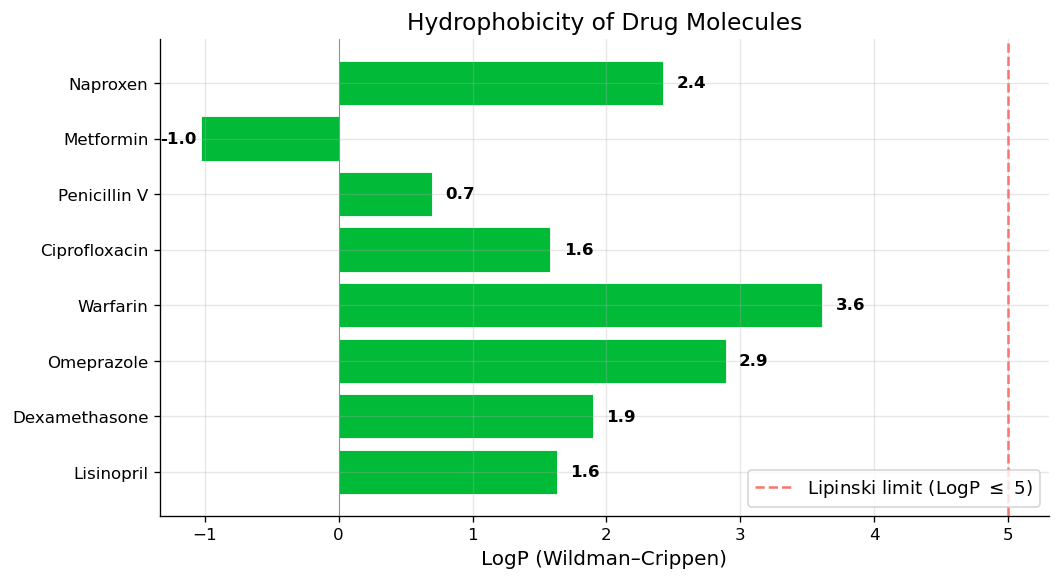

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

molecules = desc_df.index.tolist()
logp_vals = desc_df["LogP"].values
colors = [EMERALD if v <= 5 else SALMON for v in logp_vals]

bars = ax.barh(molecules, logp_vals, color=colors, edgecolor="white", linewidth=0.5)
ax.axvline(
    x=5,
    color=SALMON,
    linestyle="--",
    linewidth=1.5,
    label="Lipinski limit (LogP $\leq$ 5)",
)
ax.axvline(x=0, color="grey", linestyle="-", linewidth=0.5)
ax.set_xlabel("LogP (Wildman–Crippen)")
ax.set_title("Hydrophobicity of Drug Molecules")
ax.legend(loc="lower right")
ax.invert_yaxis()

# Annotate values on bars
for bar, val in zip(bars, logp_vals):
    x_pos = bar.get_width() + 0.1 if val >= 0 else bar.get_width() - 0.3
    ax.text(
        x_pos,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}",
        va="center",
        fontsize=10,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

---

## 4. Molecular Fingerprints and Similarity

While molecular descriptors reduce a molecule to a handful of scalar values, **molecular fingerprints** encode its substructural features into a fixed-length bit vector. Each bit position corresponds to a particular structural fragment; the bit is set to 1 if the fragment is present in the molecule and 0 otherwise.

Fingerprints are the workhorse representation for similarity searching, clustering, and many machine-learning models in cheminformatics.

### 4.1 Morgan fingerprints (Extended-Connectivity Fingerprints, ECFP)

The most widely used fingerprint in modern cheminformatics is the **Morgan fingerprint**, also known as **ECFP** (Extended-Connectivity Fingerprint). The algorithm is:

1. **Initialise:** Assign each atom an identifier based on its atomic properties (element, degree, charge, etc.).
2. **Iterate:** For each atom, gather the identifiers of all neighbours within radius $r$ bonds. Hash this neighbourhood into a new identifier.
3. **Fold:** Map all identifiers into a fixed-length bit vector of length $L$ (typically 1024 or 2048) using a hash function.

The **radius** parameter controls how far the circular environment extends around each atom:
- Radius 2 (ECFP4): captures up to 4-bond-diameter environments — the most common choice.
- Radius 3 (ECFP6): captures larger fragments, useful when more structural context matters.

#### 4.1.1 How bits are set: a visual walkthrough

Before diving into code, let's trace the full Morgan fingerprint pipeline on a single molecule. We use **aspirin** and a tiny **64-bit** vector (instead of the usual 1024) so that every bit is visible.

The figure below picks one atom and shows how its **circular environment grows** with the radius parameter. Crucially, **radius here means bond hops, not physical distance** — it is a topological radius on the molecular graph.

The Morgan "radius" counts bonds (graph hops), not Euclidean distance. It's a topological radius on the molecular graph.

Radius 1 means "all atoms reachable by traversing exactly one bond," radius 2 means "two bonds," and so on. Two atoms might be close in 3D space but far apart in bond hops (or vice versa), so this is purely a graph-theoretic notion:

- **Radius 0** — only the atom itself: its element, degree, and charge are encoded into an integer identifier (hashed).
- **Radius 1** — the atom plus all neighbours reachable within **one bond hop** (one bond away). So the its immediate neighbours form a substructure fragment. This neighbourhood is encoded into a *different* identifier via a hash function
- **Radius 2** — the environment extends to atoms within **two bond hops**, capturing a larger substructure fragment and producing yet another hash.

##### Detour: what is a hash function?

Each substructure fragment needs to be mapped to a position in the bit vector. This is the job of a [**hash function**](https://en.wikipedia.org/wiki/Hash_function) — a deterministic function that converts an input of arbitrary size (here, a description of a molecular fragment) into a fixed-size integer.

Key properties:
- **Deterministic:** the same input always produces the same output.
- **Uniform:** outputs are spread roughly evenly across the output range.
- **One-way:** you cannot reconstruct the input from the output.

A minimal example using Python's built-in `hash`:

> **Note:** Python randomises `hash()` across sessions for security, so the exact numbers above will differ each time you restart the kernel — but the properties (deterministic within a session, roughly uniform, collisions with short vectors) are always the same.

In [10]:
# ── Detour: what is a hash function and why mod L? ──

# A hash function turns ANY input into a fixed-size integer.
# Python has one built-in:
print("hash('cat') =", hash("cat"))
print("hash('dog') =", hash("dog"))
print()

# These numbers are huge — useless as array indices.
# We need to fit them into a bit vector of length L.
# That's what the modulo (%) operator does: it wraps any integer
# into the range [0, L-1], like a clock wraps hours into [0, 11].

# The MODULO operator (%) returns the remainder after division.
#   17 % 5 = 2    because 17 = 3×5 + 2
#   100 % 8 = 4   because 100 = 12×8 + 4
# It forces ANY integer into the range [0, L-1] — like a clock
# wrapping 13:00 back to 1:00.  This is how we squeeze huge hash
# values into a fixed-length bit vector.

L = 8  # tiny vector for illustration
print(f"hash('cat') % {L} = {hash('cat') % L}   ← position in an {L}-slot vector")
print(f"hash('dog') % {L} = {hash('dog') % L}")
print(f"hash('bird') % {L} = {hash('bird') % L}")
print()

# Visualise: which slots are filled?
slots = [0] * L
for word in ["cat", "dog", "bird"]:
    slots[hash(word) % L] = 1
print(f"8-bit vector: {slots}")
print(f"  (3 inputs, {sum(slots)} bits on — no collisions here)")
print()

# With more inputs the vector fills up, and COLLISIONS happen:
# two different inputs land on the same slot.
slots = [0] * L
words = ["cat", "dog", "bird", "fish", "frog", "bear", "wolf"]
collisions = []
for w in words:
    pos = hash(w) % L
    if slots[pos] == 1:
        collisions.append(w)
    slots[pos] = 1
print(f"7 inputs into {L} slots: {slots}")
print(f"  Collisions: {collisions if collisions else 'none (lucky!)'}")
print(f"  → information is lost: we can't tell which inputs set a bit.")
print()

# The fix? Use a LONGER vector. With more slots, collisions become rare.
for L in [8, 64, 1024]:
    slots = [0] * L
    n_collisions = 0
    for w in words:
        pos = hash(w) % L
        if slots[pos]:
            n_collisions += 1
        slots[pos] = 1
    print(f"  L = {L:>5d}:  {n_collisions} collisions among 7 inputs")
print()

# ── Now apply this to chemistry ──
# Morgan fingerprints do exactly the same thing, but the "inputs"
# are molecular substructure fragments instead of words:
print("— Applied to molecular fragments —")
print(f"hash('CH3-group')        % 64 = {hash('CH3-group') % 64}")
print(
    f"hash('CH3-group')        % 64 = {hash('CH3-group') % 64}   ← same input, same slot"
)
print(f"hash('OH-group')         % 64 = {hash('OH-group') % 64}")
print(
    f"hash('rare-fragment-A')  % 64 = {hash('rare-fragment-A') % 64}  ← might collide!"
)


hash('cat') = -988547091883884367
hash('dog') = 5772701429291802828

hash('cat') % 8 = 1   ← position in an 8-slot vector
hash('dog') % 8 = 4
hash('bird') % 8 = 0

8-bit vector: [1, 1, 0, 0, 1, 0, 0, 0]
  (3 inputs, 3 bits on — no collisions here)

7 inputs into 8 slots: [1, 1, 1, 0, 1, 0, 0, 0]
  Collisions: ['fish', 'frog', 'wolf']
  → information is lost: we can't tell which inputs set a bit.

  L =     8:  3 collisions among 7 inputs
  L =    64:  0 collisions among 7 inputs
  L =  1024:  0 collisions among 7 inputs

— Applied to molecular fragments —
hash('CH3-group')        % 64 = 44
hash('CH3-group')        % 64 = 44   ← same input, same slot
hash('OH-group')         % 64 = 62
hash('rare-fragment-A')  % 64 = 52  ← might collide!


##### Why modulo? From big numbers to small positions

Now that we know what a hash function does, one question remains: the hash output is a huge integer (often billions), but our bit vector has only $L$ slots. How do we squeeze a giant number into a small range?

The answer is the **modulo operator** (`%`), which returns the *remainder* after division. The key insight: `any_number % L` is always in the range $[0, L{-}1]$, no matter how large the input. It acts like a clock — the number "wraps around" every $L$ steps and always lands on a valid slot.

But what happens when two different hash values give the **same** remainder? This is a **collision** — two different substructures end up setting the same bit. When that happens, we lose information: we know *something* set that bit, but we can't tell whether it was one fragment or two.

This is the fundamental trade-off of fingerprints:
- **Shorter vector** (small $L$): more collisions, less precise, but cheaper to store and compare.
- **Longer vector** (large $L$): fewer collisions, more faithful representation of the molecule.

In practice, $L = 1024$ or $2048$ is long enough that collisions are rare and the fingerprint remains highly informative. The figure below traces three hash values through this process into a tiny 8-bit vector, where collisions are easy to spot.

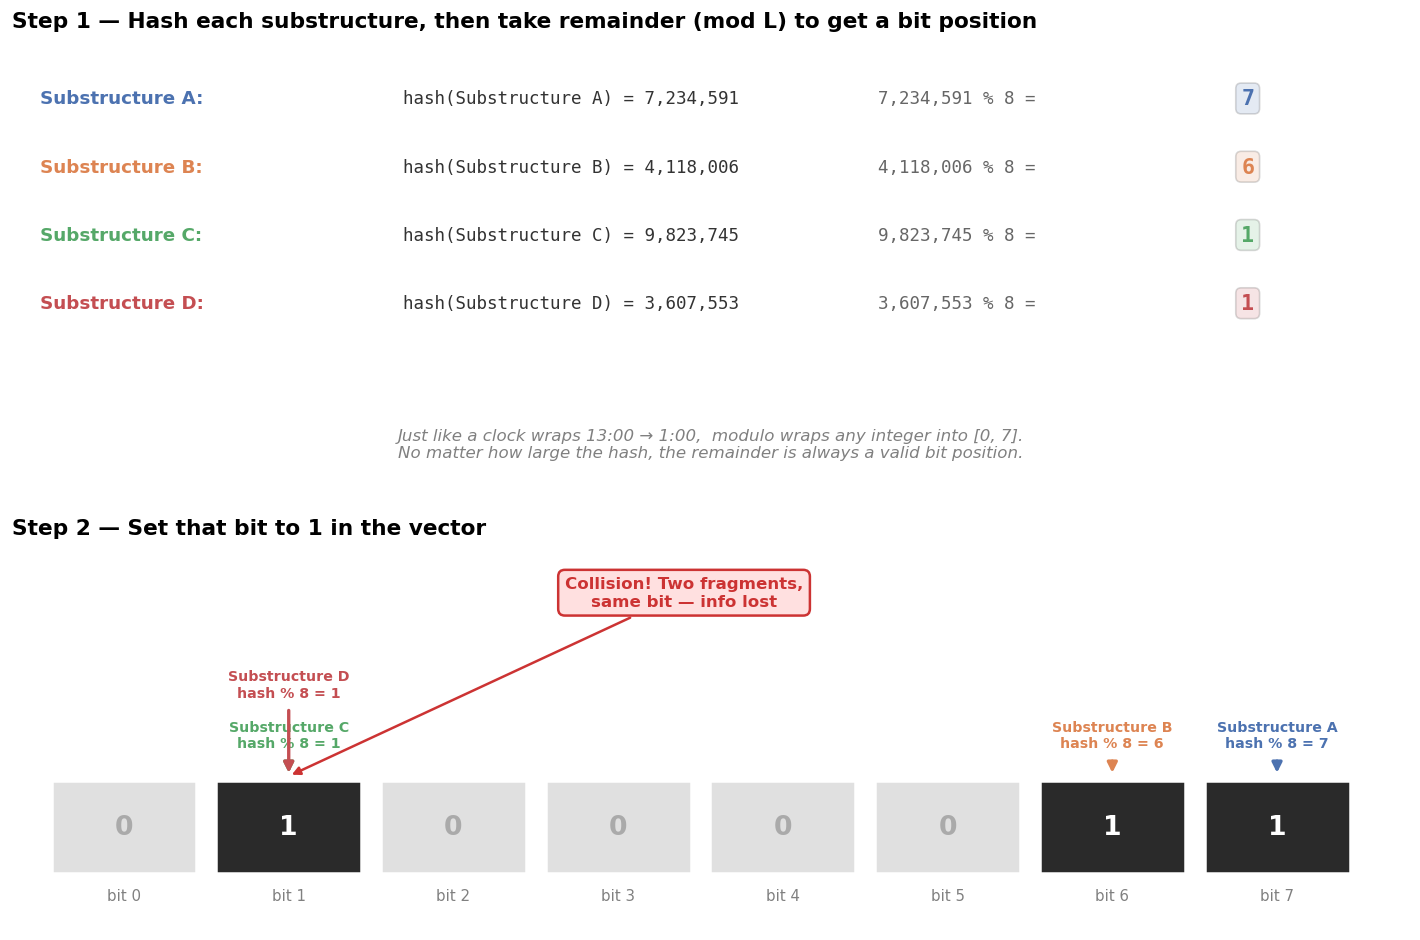

In [ ]:
# ── Visual explanation: how modulo folds hash values into a bit vector ──

fig, axes = plt.subplots(
    3, 1, figsize=(12, 8), gridspec_kw={"height_ratios": [1.4, 0.5, 1.8]}
)

L = 8  # tiny vector for clarity
examples = [
    ("Substructure A", 7_234_591, "#4C72B0"),  # % 8 = 7
    ("Substructure B", 4_118_006, "#DD8452"),  # % 8 = 6
    ("Substructure C", 9_823_745, "#55A868"),  # % 8 = 1
    ("Substructure D", 3_607_553, "#C44E52"),  # % 8 = 1  ← collides with C!
]


# ── Top panel: the division / remainder calculation ──
ax_calc = axes[0]
ax_calc.axis("off")
ax_calc.set_xlim(0, 10)
ax_calc.set_ylim(-0.5, len(examples) - 0.2)
ax_calc.set_title(
    "Step 1 — Hash each substructure, then take remainder (mod L) to get a bit position",
    fontsize=13,
    fontweight="bold",
    loc="left",
    pad=10,
)

for i, (name, hval, col) in enumerate(examples):
    y = len(examples) - 1 - i
    remainder = hval % L
    quotient = hval // L
    ax_calc.text(
        0.2, y, f"{name}:", fontsize=11, fontweight="bold", color=col, va="center"
    )

    ax_calc.text(
        2.8,
        y,
        f"hash({name}) = {hval:,}",
        fontsize=10.5,
        va="center",
        color="#333333",
        family="monospace",
    )
    ax_calc.text(
        6.2,
        y,
        f"{hval:,} % {L} = ",
        fontsize=10.5,
        va="center",
        color="#666666",
        family="monospace",
    )

    ax_calc.text(
        8.8,
        y,
        f"{remainder}",
        fontsize=13,
        fontweight="bold",
        va="center",
        color=col,
        family="monospace",
        bbox=dict(boxstyle="round,pad=0.25", fc=col, alpha=0.15),
    )

# ── Middle panel: the "clock" analogy ──
ax_mid = axes[1]
ax_mid.axis("off")
ax_mid.text(
    0.5,
    0.5,
    f"Just like a clock wraps 13:00 → 1:00,  modulo wraps any integer into [0, {L - 1}].\n"
    f"No matter how large the hash, the remainder is always a valid bit position.",
    ha="center",
    va="center",
    fontsize=10,
    fontstyle="italic",
    color="gray",
    transform=ax_mid.transAxes,
)

# ── Bottom panel: the 8-bit vector being filled ──
ax_bv = axes[2]
ax_bv.set_title(
    "Step 2 — Set that bit to 1 in the vector",
    fontsize=13,
    fontweight="bold",
    loc="left",
    pad=10,
)

bit_vec = [0] * L
bit_sources = {}  # pos -> list of (name, color)
for name, hval, col in examples:
    pos = hval % L
    bit_vec[pos] = 1
    bit_sources.setdefault(pos, []).append((name, col))

for pos in range(L):
    is_on = bit_vec[pos] == 1
    fc = "#2a2a2a" if is_on else "#e0e0e0"
    tc = "white" if is_on else "#aaaaaa"

    # Draw the bit cell (wider for readability)
    cell_w = 1.1
    x = pos * (cell_w + 0.15)
    rect = plt.Rectangle((x, 0.3), cell_w, 1.0, fc=fc, ec="white", lw=1.5, zorder=2)
    ax_bv.add_patch(rect)
    ax_bv.text(
        x + cell_w / 2,
        0.8,
        str(bit_vec[pos]),
        ha="center",
        va="center",
        fontsize=16,
        fontweight="bold",
        color=tc,
        zorder=3,
    )
    # Bit index below
    ax_bv.text(
        x + cell_w / 2,
        0.05,
        f"bit {pos}",
        ha="center",
        va="center",
        fontsize=9,
        color="gray",
    )

    # Arrows + labels from hash values that land here
    if pos in bit_sources:
        for j, (name, col) in enumerate(bit_sources[pos]):
            y_arrow = 1.55 + j * 0.55
            ax_bv.annotate(
                "",
                xy=(x + cell_w / 2, 1.35),
                xytext=(x + cell_w / 2, y_arrow),
                arrowprops=dict(arrowstyle="-|>", color=col, lw=2),
                zorder=4,
            )
            ax_bv.text(
                x + cell_w / 2,
                y_arrow + 0.08,
                f"{name}\nhash % {L} = {pos}",
                ha="center",
                va="bottom",
                fontsize=8.5,
                fontweight="bold",
                color=col,
            )

ax_bv.set_xlim(-0.3, L * 1.25 + 0.3)
ax_bv.set_ylim(-0.3, 3.8)
ax_bv.axis("off")

# Collision callout on bit 1
collision_pos = 1
cx = collision_pos * (cell_w + 0.15) + cell_w / 2
ax_bv.annotate(
    "Collision! Two fragments,\nsame bit — info lost",
    xy=(cx, 1.35),
    xytext=(cx + 3.0, 3.2),
    fontsize=10,
    fontweight="bold",
    color="#cc3333",
    ha="center",
    arrowprops=dict(arrowstyle="-|>", color="#cc3333", lw=1.5),
    bbox=dict(boxstyle="round,pad=0.4", fc="#ffe0e0", ec="#cc3333", lw=1.5),
)

plt.tight_layout()
plt.show()

### Visualizing the Process of creating Morgan fingerprints
In the figure below each `molecular` hash is **folded** into the bit vector by taking `hash mod L` (where `L` is the vector length). The bit at that position is set to **1**. The algorithm repeats this for *every* atom at *every* radius, so the final vector is the union of all environments in the molecule.

Because many possible substructures are squeezed into a short vector, two different fragments may land on the same bit — a **bit collision**. In practice, using 1024 or 2048 bits keeps collisions rare enough to be harmless.

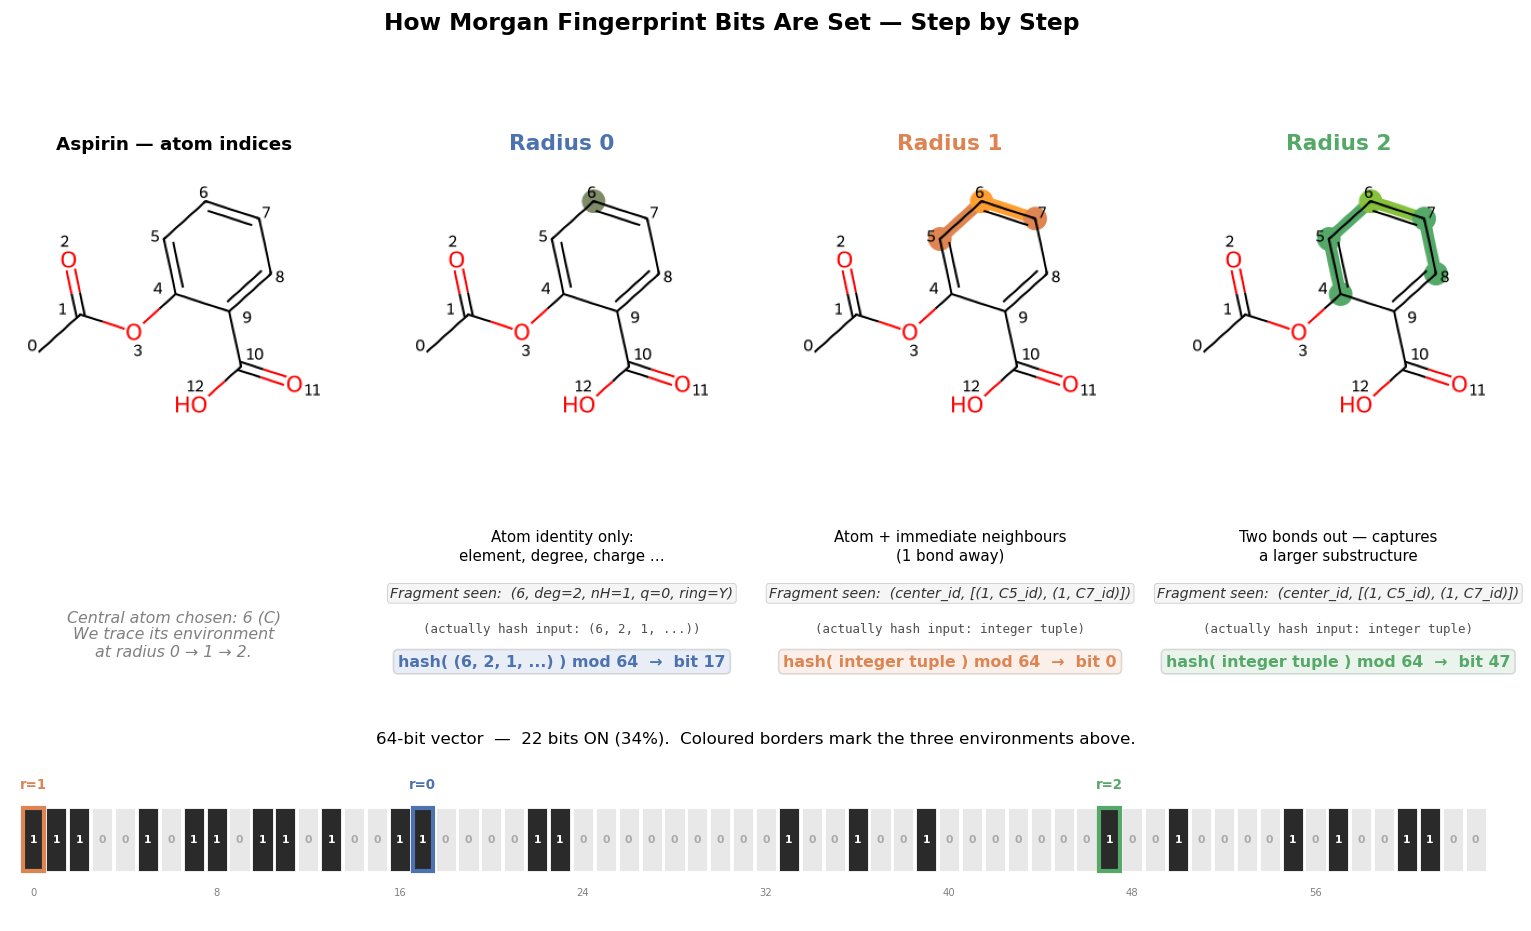

In [ ]:
# ── Visual walkthrough: how Morgan fingerprint bits are set ──
from rdkit.Chem.Draw import rdMolDraw2D
from io import BytesIO
from PIL import Image

demo_mol = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")  # aspirin
Chem.rdDepictor.Compute2DCoords(demo_mol)

# Generate a small (64-bit) fingerprint and record which (atom, radius) set each bit
FP_LEN = 64
bit_info = {}
morgan_gen_demo = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=FP_LEN)

# AdditionalOutput captures the bit → (atom, radius) mapping
ao = rdFingerprintGenerator.AdditionalOutput()
ao.AllocateBitInfoMap()
demo_fp = morgan_gen_demo.GetFingerprint(demo_mol, additionalOutput=ao)
bit_info = ao.GetBitInfoMap()

# For each atom, collect which radii contributed a bit
atom_bits = {}  # atom_idx → {radius: bit_position}
for bit, envs in bit_info.items():
    for atom_idx, rad in envs:
        atom_bits.setdefault(atom_idx, {})[rad] = bit

# Pick the atom that has environments at all three radii (0, 1, 2)
central = max(atom_bits, key=lambda a: len(atom_bits[a]))
radii = sorted(atom_bits[central].keys())[:3]


# ── Helpers ──
def get_env(mol, center, radius):
    """Return (atom_indices, bond_indices) within `radius` of `center`."""
    if radius == 0:
        return [center], []
    bonds = list(Chem.FindAtomEnvironmentOfRadiusN(mol, radius, center))
    atoms = {center}
    for bi in bonds:
        b = mol.GetBondWithIdx(bi)
        atoms.add(b.GetBeginAtomIdx())
        atoms.add(b.GetEndAtomIdx())
    return list(atoms), bonds


def draw_mol(mol, hi_atoms=None, hi_bonds=None, hi_colors=None, size=(300, 260)):
    """Render molecule to PIL Image with optional highlighting."""
    d = rdMolDraw2D.MolDraw2DCairo(size[0], size[1])
    d.drawOptions().addAtomIndices = True
    d.drawOptions().annotationFontScale = 0.7
    kw = {}
    if hi_atoms is not None:
        kw["highlightAtoms"] = hi_atoms
    if hi_bonds is not None:
        kw["highlightBonds"] = hi_bonds
    if hi_colors is not None:
        kw["highlightAtomColors"] = hi_colors
    d.DrawMolecule(mol, **kw)
    d.FinishDrawing()
    return Image.open(BytesIO(d.GetDrawingText()))


# ── Colour scheme per radius ──
PAL = {0: (0.30, 0.45, 0.69), 1: (0.87, 0.52, 0.32), 2: (0.33, 0.66, 0.41)}
PAL_HEX = {0: "#4C72B0", 1: "#DD8452", 2: "#55A868"}
RAD_DESC = {
    0: "Atom identity only:\nelement, degree, charge …",
    1: "Atom + immediate neighbours\n(1 bond away)",
    2: "Two bonds out — captures\na larger substructure",
}

# ── Build figure ──
n_cols = 1 + len(radii)
fig = plt.figure(figsize=(4 * n_cols, 8.5))
gs = fig.add_gridspec(3, n_cols, height_ratios=[2.6, 0.7, 1.0], hspace=0.25, wspace=0.2)

# Column 0: full molecule with atom indices, no highlighting
ax0 = fig.add_subplot(gs[0, 0])
ax0.imshow(draw_mol(demo_mol))
ax0.set_title("Aspirin — atom indices", fontsize=11, fontweight="bold")
ax0.axis("off")

sym = demo_mol.GetAtomWithIdx(central).GetSymbol()
ax0d = fig.add_subplot(gs[1, 0])
ax0d.axis("off")
ax0d.text(
    0.5,
    0.5,
    f"Central atom chosen: {central} ({sym})\n"
    "We trace its environment\nat radius 0 → 1 → 2.",
    ha="center",
    va="center",
    fontsize=9.5,
    fontstyle="italic",
    color="gray",
    transform=ax0d.transAxes,
)


# ── Helper: describe what the hash function "sees" at each radius ──
def fragment_label(mol, center, radius):
    """Build a realistic label of the integer tuple fed to the hash."""
    atom = mol.GetAtomWithIdx(center)
    if radius == 0:
        # Actual ECFP initial invariants
        return (
            f"({atom.GetAtomicNum()}, deg={atom.GetDegree()}, "
            f"nH={atom.GetTotalNumHs()}, q={atom.GetFormalCharge()}, "
            f"ring={'Y' if atom.IsInRing() else 'N'})"
        )
    # For r ≥ 1: current_id + sorted neighbour info
    atoms_in_env, _ = get_env(mol, center, radius)
    # Show the structure: center's properties + neighbour bond/id pairs
    nbrs = []
    for nb in atom.GetNeighbors():
        bond = mol.GetBondBetweenAtoms(center, nb.GetIdx())
        btype = int(bond.GetBondTypeAsDouble())
        nbrs.append(f"({btype}, {nb.GetSymbol()}{nb.GetIdx()}_id)")
    nbrs_str = ", ".join(sorted(nbrs))
    return f"(center_id, [{nbrs_str}])"


def fragment_label_short(mol, center, radius):
    """Shorter version for the hash() line."""
    atom = mol.GetAtomWithIdx(center)
    if radius == 0:
        return (
            f"({atom.GetAtomicNum()}, {atom.GetDegree()}, {atom.GetTotalNumHs()}, ...)"
        )
    return "integer tuple"


# Columns 1–3: one per radius, highlighting the growing environment
for col, rad in enumerate(radii, start=1):
    atoms, bonds = get_env(demo_mol, central, rad)
    r, g, b = PAL[rad]
    colors = {a: (r, g, b) for a in atoms}
    colors[central] = (min(r + 0.2, 1), min(g + 0.1, 1), b * 0.6)

    ax = fig.add_subplot(gs[0, col])
    ax.imshow(draw_mol(demo_mol, hi_atoms=atoms, hi_bonds=bonds, hi_colors=colors))
    ax.set_title(f"Radius {rad}", fontsize=13, fontweight="bold", color=PAL_HEX[rad])
    ax.axis("off")

    # Description + fragment input + hash → bit
    ax_d = fig.add_subplot(gs[1, col])
    ax_d.axis("off")
    bit_pos = atom_bits[central][rad]
    frag = fragment_label(demo_mol, central, rad)

    # What this radius means
    ax_d.text(
        0.5,
        1.4,
        RAD_DESC[rad],
        ha="center",
        va="top",
        fontsize=9,
        transform=ax_d.transAxes,
        linespacing=1.3,
    )
    # Intuitive fragment label (atom symbols)
    ax_d.text(
        0.5,
        0.85,
        f"Fragment seen:  {frag}",
        ha="center",
        va="center",
        fontsize=8.5,
        fontstyle="italic",
        color="#333333",
        transform=ax_d.transAxes,
        bbox=dict(boxstyle="round,pad=0.2", fc="#f5f5f5", ec="#cccccc", lw=0.5),
    )
    # # What RDKit actually hashes (integer tuple)
    frag_short = fragment_label_short(demo_mol, central, rad)
    ax_d.text(
        0.5,
        0.55,
        f"(actually hash input: {frag_short})",
        ha="center",
        va="center",
        fontsize=7.5,
        family="monospace",
        color="#4E4E4E",
        transform=ax_d.transAxes,
    )
    # hash → bit position

    frag_short = fragment_label_short(demo_mol, central, rad)
    ax_d.text(
        0.5,
        0.2,
        f"hash( {frag_short} ) mod {FP_LEN}  →  bit {bit_pos}",
        ha="center",
        va="bottom",
        fontsize=9.5,
        fontweight="bold",
        color=PAL_HEX[rad],
        transform=ax_d.transAxes,
        bbox=dict(boxstyle="round,pad=0.3", fc=PAL_HEX[rad], alpha=0.12),
    )


# ── Bottom row: the bit vector ──
ax_bv = fig.add_subplot(gs[2, :])
on_bits = set(demo_fp.GetOnBits())

for pos in range(FP_LEN):
    is_on = pos in on_bits
    fc, tc = ("#2a2a2a", "white") if is_on else ("#e8e8e8", "#aaaaaa")
    ax_bv.add_patch(plt.Rectangle((pos, 0), 0.88, 0.8, fc=fc, ec="white", lw=0.5))
    ax_bv.text(
        pos + 0.44,
        0.4,
        str(int(is_on)),
        ha="center",
        va="center",
        fontsize=6.5,
        fontweight="bold",
        color=tc,
    )
    if pos % 8 == 0:
        ax_bv.text(pos + 0.44, -0.3, str(pos), ha="center", fontsize=6, color="gray")

# Coloured borders on the three example bits
for rad in radii:
    bp = atom_bits[central][rad]
    ax_bv.add_patch(
        plt.Rectangle((bp, 0), 0.88, 0.8, fc="none", ec=PAL_HEX[rad], lw=2.5, zorder=5)
    )
    ax_bv.text(
        bp + 0.44,
        1.05,
        f"r={rad}",
        ha="center",
        fontsize=8,
        fontweight="bold",
        color=PAL_HEX[rad],
    )

n_on = len(on_bits)
ax_bv.set_xlim(-0.5, FP_LEN + 0.5)
ax_bv.set_ylim(-0.6, 1.5)
ax_bv.axis("off")
ax_bv.set_title(
    f"{FP_LEN}-bit vector  —  {n_on} bits ON ({n_on / FP_LEN * 100:.0f}%).  "
    "Coloured borders mark the three environments above.",
    fontsize=10,
    pad=6,
)

fig.suptitle(
    "How Morgan Fingerprint Bits Are Set — Step by Step",
    fontsize=14,
    fontweight="bold",
    y=1.0,
)
fig.subplots_adjust(hspace=0.3, wspace=0.2, top=0.93)
plt.show()

### 4.2 Tanimoto similarity

Given two binary fingerprint vectors $A$ and $B$, the **Tanimoto coefficient** (also called the Jaccard index) measures their overlap:

$$T(A, B) = \frac{|A \cap B|}{|A \cup B|} = \frac{c}{a + b - c}$$

where:
- $a = |A|$ = number of bits set to 1 in $A$,
- $b = |B|$ = number of bits set to 1 in $B$,
- $c = |A \cap B|$ = number of bit positions that are 1 in both $A$ and $B$.

The Tanimoto coefficient ranges from 0 (no bits in common) to 1 (identical fingerprints). In practice:
- $T > 0.85$: molecules are considered very similar.
- $T > 0.7$: moderate structural similarity.
- $T < 0.5$: structurally dissimilar.

### 4.3 The molecular similarity principle

The **molecular similarity principle** states that *structurally similar molecules tend to have similar biological activities and physical properties*. This is the foundational assumption behind virtually all ligand-based drug discovery: if compound A is active and compound B is structurally similar to A, then B is a good candidate to test.

Of course, this principle has exceptions ("activity cliffs" — small structural changes causing large activity changes), but it holds well enough to be enormously useful in practice.

Below we compute Morgan fingerprints (radius 2, 1024 bits) for six molecules. We include ibuprofen alongside naproxen — both are NSAIDs with similar pharmacology — to illustrate that the Tanimoto coefficient captures functional similarity.

In [ ]:
# Molecules for fingerprint comparison
fp_drugs = {
    "Naproxen": "CC(C1=CC2=C(C=C1)C=C(C2)OC)C(=O)O",
    "Ibuprofen": "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O",
    "Metformin": "CN(C)C(=N)NC(=N)N",
    "Ciprofloxacin": "C1CC1N2C=C(C(=O)C3=CC(=C(C=C32)N4CCNCC4)F)C(=O)O",
    "Warfarin": "CC(=O)CC(C1=CC=CC=C1)C2=C(C3=CC=CC=C3OC2=O)O",
    "Dexamethasone": "CC1CC2C3CCC4=CC(=O)C=CC4(C3(C(CC2(C1(C(=O)CO)O)C)O)F)C",
}

# Generate Morgan fingerprints using the modern rdFingerprintGenerator API
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

fp_dict = {}
for name, smi in fp_drugs.items():
    mol = Chem.MolFromSmiles(smi)
    fp = morgan_gen.GetFingerprint(mol)
    fp_dict[name] = fp
    n_on = fp.GetNumOnBits()
    print(f"{name:16s}  bits on: {n_on:3d} / 1024  ({n_on / 1024 * 100:.1f}%)")

Naproxen          bits on:  35 / 1024  (3.4%)
Ibuprofen         bits on:  25 / 1024  (2.4%)
Metformin         bits on:  17 / 1024  (1.7%)
Ciprofloxacin     bits on:  45 / 1024  (4.4%)
Warfarin          bits on:  37 / 1024  (3.6%)
Dexamethasone     bits on:  54 / 1024  (5.3%)


Now we compute the pairwise Tanimoto similarity matrix and display it as a heatmap. We expect naproxen and ibuprofen (both arylpropionic acid NSAIDs) to have the highest off-diagonal similarity.

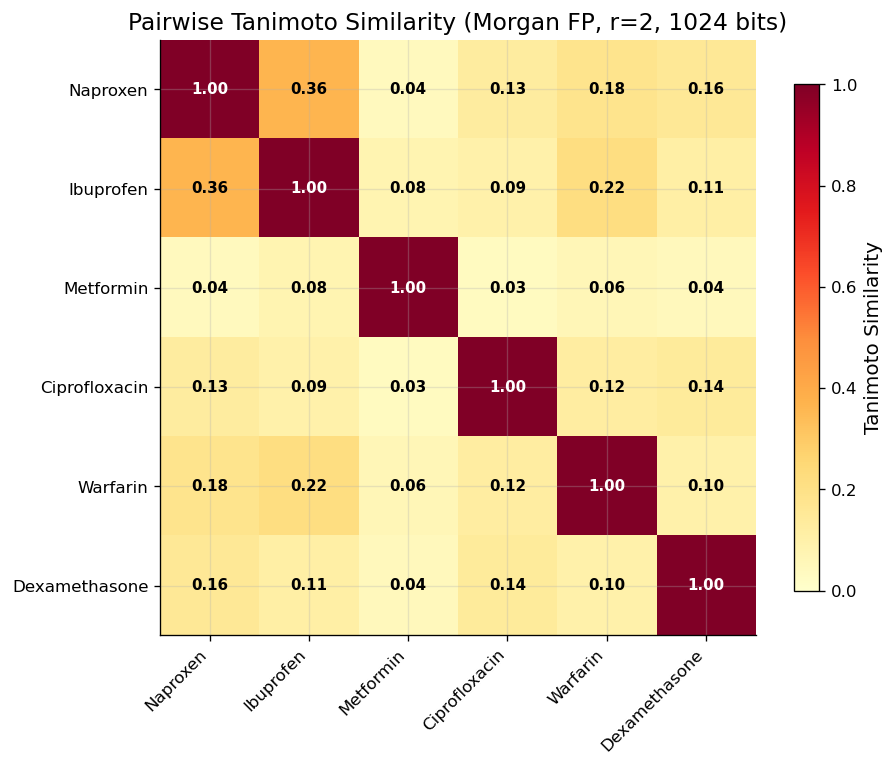

In [ ]:
mol_names = list(fp_dict.keys())
n = len(mol_names)
sim_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = DataStructs.TanimotoSimilarity(
            fp_dict[mol_names[i]], fp_dict[mol_names[j]]
        )

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(sim_matrix, cmap="YlOrRd", vmin=0, vmax=1)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(mol_names, rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(mol_names, fontsize=10)
ax.set_title("Pairwise Tanimoto Similarity (Morgan FP, r=2, 1024 bits)")

# Annotate cells
for i in range(n):
    for j in range(n):
        val = sim_matrix[i, j]
        text_color = "white" if val > 0.6 else "black"
        ax.text(
            j,
            i,
            f"{val:.2f}",
            ha="center",
            va="center",
            fontsize=9,
            color=text_color,
            fontweight="bold",
        )

plt.colorbar(im, ax=ax, label="Tanimoto Similarity", shrink=0.85)
plt.tight_layout()
plt.show()

As expected, naproxen and ibuprofen show the highest pairwise similarity among the off-diagonal entries. Both share an arylpropionic acid scaffold. Metformin, being a small biguanide with no aromatic ring, is structurally dissimilar to all other molecules in the set.

---

## 5. Molecular Editing

One of RDKit's most powerful features is the ability to **programmatically edit molecular structures**. This mirrors what medicinal chemists do at the bench: make small, targeted changes to a molecule and observe how the change affects its properties. In computational chemistry, this is called **structure-activity relationship (SAR) exploration**.

Two common strategies are:

1. **Bioisosteric replacement:** Swapping one functional group for another that has similar size, shape, or electronic properties. A classic example is replacing chlorine with fluorine — both are halogens, but fluorine is smaller and forms a stronger C–F bond, which can improve metabolic stability.

2. **Prodrug design:** Masking a polar functional group (e.g., converting a carboxylic acid –COOH into an ester –COOCH$_3$) to improve membrane permeability. The body's enzymes later unmask the active form.

RDKit provides `Chem.ReplaceSubstructs()` for substructure find-and-replace on molecular graphs.

### 5.1 Bioisosteric replacement: Cl to F

Below we take a chlorinated aromatic compound and replace the chlorine atom with fluorine. This is a common medicinal chemistry transformation because the C–F bond is more resistant to oxidative metabolism.

Original:    CNC(=O)c1ccc(Cl)cc1
After Cl->F: CNC(=O)c1ccc(F)cc1


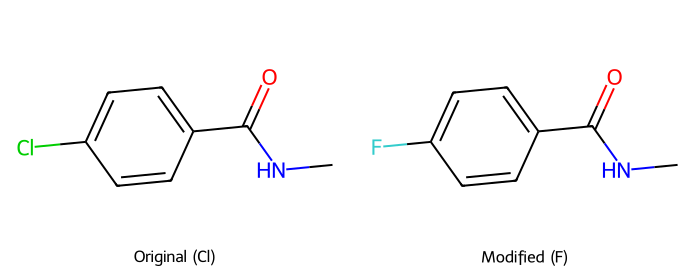

In [10]:
# Start with a chlorinated aromatic (a simplified chlorobenzamide)
mol_cl = Chem.MolFromSmiles("ClC1=CC=C(C(=O)NC)C=C1")

# Define patterns for search and replacement
cl_pattern = Chem.MolFromSmiles("Cl")
f_replacement = Chem.MolFromSmiles("F")

# Perform the replacement
products = Chem.ReplaceSubstructs(mol_cl, cl_pattern, f_replacement)
mol_f = products[0]
Chem.SanitizeMol(mol_f)

print(f"Original:    {Chem.MolToSmiles(mol_cl)}")
print(f"After Cl->F: {Chem.MolToSmiles(mol_f)}")

# Draw side by side
Draw.MolsToGridImage(
    [mol_cl, mol_f],
    legends=["Original (Cl)", "Modified (F)"],
    subImgSize=(350, 280),
    molsPerRow=2,
)

### 5.2 Prodrug strategy: carboxylic acid to methyl ester

Converting a carboxylic acid (–COOH) to a methyl ester (–COOCH$_3$) reduces polarity and can improve oral absorption. We demonstrate this on naproxen.

Naproxen (acid):  COC1=Cc2ccc(C(C)C(=O)O)cc2C1
Naproxen (ester): COC(=O)C(C)c1ccc2c(c1)CC(OC)=C2

LogP (acid):  2.42
LogP (ester): 2.51
Change:       +0.09 (more lipophilic, as expected)


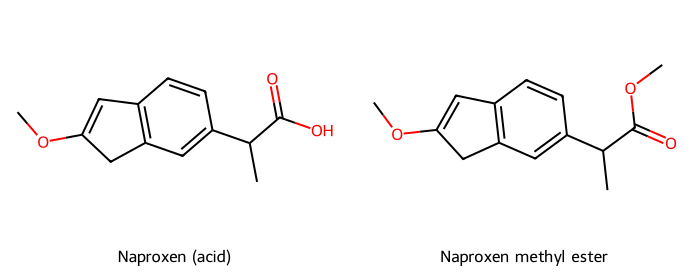

In [ ]:
# Naproxen: replace -C(=O)O (carboxylic acid) with -C(=O)OC (methyl ester)
naproxen_mol = Chem.MolFromSmiles("CC(C1=CC2=C(C=C1)C=C(C2)OC)C(=O)O")

acid_pattern = Chem.MolFromSmarts("[CX3](=O)[OX2H1]")
ester_replacement = Chem.MolFromSmiles("C(=O)OC")

products = Chem.ReplaceSubstructs(naproxen_mol, acid_pattern, ester_replacement)
naproxen_ester = products[0]
Chem.SanitizeMol(naproxen_ester)

print(f"Naproxen (acid):  {Chem.MolToSmiles(naproxen_mol)}")
print(f"Naproxen (ester): {Chem.MolToSmiles(naproxen_ester)}")

# Compare LogP — ester should be more lipophilic
logp_acid = Crippen.MolLogP(naproxen_mol)
logp_ester = Crippen.MolLogP(naproxen_ester)
print(f"\nLogP (acid):  {logp_acid:.2f}")
print(f"LogP (ester): {logp_ester:.2f}")
print(f"Change:       +{logp_ester - logp_acid:.2f} (more lipophilic, as expected)")

Draw.MolsToGridImage(
    [naproxen_mol, naproxen_ester],
    legends=["Naproxen (acid)", "Naproxen methyl ester"],
    subImgSize=(350, 280),
    molsPerRow=2,
)

---

## 6. Building a Molecular Dataset

In practice, we rarely work with one molecule at a time. Drug-discovery datasets contain thousands to millions of compounds, each described by SMILES, descriptors, and assay results. In this section we build a small but realistic molecular DataFrame — the kind of data that feeds into the QSAR models of the next notebooks.

We collect 20 well-known drugs, compute their descriptors using RDKit, and perform exploratory data analysis.

The following cell defines a curated list of 20 drug molecules with their SMILES strings and computes descriptors for each.

In [ ]:
# Curated set of 20 drug molecules
drug_library = {
    "Naproxen": "CC(C1=CC2=C(C=C1)C=C(C2)OC)C(=O)O",
    "Metformin": "CN(C)C(=N)NC(=N)N",
    "Penicillin V": "CC1(C(N2C(S1)C(C2=O)NC(=O)COC3=CC=CC=C3)C(=O)O)C",
    "Ciprofloxacin": "C1CC1N2C=C(C(=O)C3=CC(=C(C=C32)N4CCNCC4)F)C(=O)O",
    "Warfarin": "CC(=O)CC(C1=CC=CC=C1)C2=C(C3=CC=CC=C3OC2=O)O",
    "Omeprazole": "CC1=CN=C(C(=C1OC)C)CS(=O)C2=NC3=CC=CC=C3N2",
    "Dexamethasone": "CC1CC2C3CCC4=CC(=O)C=CC4(C3(C(CC2(C1(C(=O)CO)O)C)O)F)C",
    "Lisinopril": "C(CC(C(=O)O)NC(CCCCN)C(=O)O)CC1=CC=CC=C1",
    "Amlodipine": "CCOC(=O)C1=C(NC(=C(C1C2=CC=CC=C2Cl)C(=O)OC)C)COCCN",
    "Atorvastatin": "CC(C)C1=C(C(=C(N1CCC(CC(CC(=O)O)O)O)C2=CC=C(C=C2)F)C3=CC=CC=C3)C(=O)NC4=CC=CC=C4",
    "Ibuprofen": "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O",
    "Diclofenac": "OC(=O)CC1=CC=CC=C1NC2=C(Cl)C=CC(Cl)=C2",
    "Metoprolol": "CC(C)NCC(COC1=CC=C(CCOC)C=C1)O",
    "Losartan": "CCCCC1=NC(=C(N1CC2=CC=C(C=C2)C3=CC=CC=C3C4=NNN=N4)CO)Cl",
    "Fluoxetine": "CNCCC(C1=CC=CC=C1)OC2=CC=C(C=C2)C(F)(F)F",
    "Amoxicillin": "CC1(C(N2C(S1)C(C2=O)NC(=O)C(C3=CC=C(C=C3)O)N)C(=O)O)C",
    "Ranitidine": "CNC(/C=C/[N+](=O)[O-])=N\\CSCC1=CC=C(CN(C)C)O1",
    "Simvastatin": "CCC(C)(C)C(=O)OC1CC(C=C2C1C(C(C=C2)C)CCC3CC(CC(=O)O3)O)C",
    "Cetirizine": "C1=CC=C(C=C1)C(CCN2CCCOCC2)OC3=CC=C(C=C3)Cl",
    "Sildenafil": "CCCC1=NN(C2=C1N=C(NC2=O)C3=C(C=CC(=C3)S(=O)(=O)N4CCN(CC4)C)OCC)C",
}


def compute_descriptors(smi):
    """Compute key molecular descriptors from a SMILES string."""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    mw = Descriptors.MolWt(mol)
    logp = Crippen.MolLogP(mol)
    hbd = rdMolDescriptors.CalcNumHBD(mol)
    hba = rdMolDescriptors.CalcNumHBA(mol)
    tpsa = rdMolDescriptors.CalcTPSA(mol)
    rotb = rdMolDescriptors.CalcNumRotatableBonds(mol)
    arom = rdMolDescriptors.CalcNumAromaticRings(mol)
    heavy = mol.GetNumHeavyAtoms()

    # Lipinski violations
    violations = sum([mw > 500, logp > 5, hbd > 5, hba > 10])
    lipinski_pass = violations < 2

    return {
        "MW": round(mw, 1),
        "LogP": round(logp, 2),
        "HBD": hbd,
        "HBA": hba,
        "TPSA": round(tpsa, 1),
        "RotBonds": rotb,
        "AromaticRings": arom,
        "HeavyAtoms": heavy,
        "Lipinski_Violations": violations,
        "Lipinski_Pass": lipinski_pass,
    }


# Build the DataFrame
records = []
for name, smi in drug_library.items():
    desc = compute_descriptors(smi)
    if desc is not None:
        desc["Molecule"] = name
        desc["SMILES"] = smi
        records.append(desc)

mol_df = pd.DataFrame(records)
mol_df = mol_df[
    [
        "Molecule",
        "SMILES",
        "MW",
        "LogP",
        "HBD",
        "HBA",
        "TPSA",
        "RotBonds",
        "AromaticRings",
        "HeavyAtoms",
        "Lipinski_Violations",
        "Lipinski_Pass",
    ]
]
mol_df = mol_df.set_index("Molecule")

print(f"Dataset: {len(mol_df)} molecules, {mol_df.shape[1]} features")
mol_df

Dataset: 20 molecules, 11 features


,SMILES,MW,LogP,HBD,HBA,TPSA,RotBonds,AromaticRings,HeavyAtoms,Lipinski_Violations,Lipinski_Pass
Molecule,,,,,,,,,,,
Naproxen,CC(C1=CC2=C(C=C1)C=C(C2)OC)C(=O)O,218.3,2.42,1,2,46.5,3,1,16,0,True
Metformin,CN(C)C(=N)NC(=N)N,129.2,-1.03,4,2,89.0,0,0,9,0,True
Penicillin V,CC1(C(N2C(S1)C(C2=O)NC(=O)COC3=CC=CC=C3)C(=O)O)C,350.4,0.70,2,5,95.9,5,1,24,0,True
Ciprofloxacin,C1CC1N2C=C(C(=O)C3=CC(=C(C=C32)N4CCNCC4)F)C(=O)O,331.3,1.58,2,4,74.6,3,2,24,0,True
Warfarin,CC(=O)CC(C1=CC=CC=C1)C2=C(C3=CC=CC=C3OC2=O)O,308.3,3.61,1,4,67.5,4,3,23,0,True
Omeprazole,CC1=CN=C(C(=C1OC)C)CS(=O)C2=NC3=CC=CC=C3N2,315.4,2.89,1,4,67.9,4,3,22,0,True
Dexamethasone,CC1CC2C3CCC4=CC(=O)C=CC4(C3(C(CC2(C1(C(=O)CO)O...,392.5,1.90,3,5,94.8,2,0,28,0,True
Lisinopril,C(CC(C(=O)O)NC(CCCCN)C(=O)O)CC1=CC=CC=C1,322.4,1.63,4,4,112.6,12,1,23,0,True
Amlodipine,CCOC(=O)C1=C(NC(=C(C1C2=CC=CC=C2Cl)C(=O)OC)C)C...,408.9,2.27,2,7,99.9,8,1,28,0,True


### 6.1 Distribution of molecular weight

The histogram below shows the distribution of molecular weights in our drug set. Most approved oral drugs fall between 150 and 500 Da. The Lipinski threshold of 500 Da is marked as a dashed line.

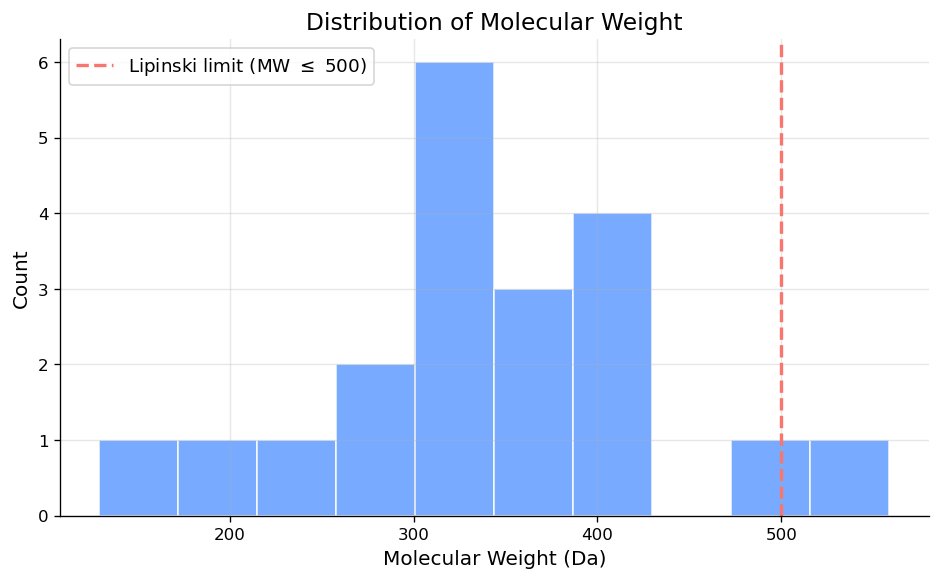

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(mol_df["MW"], bins=10, color=PERIWINKLE, edgecolor="white", alpha=0.85)
ax.axvline(
    x=500,
    color=SALMON,
    linestyle="--",
    linewidth=2,
    label="Lipinski limit (MW $\leq$ 500)",
)
ax.set_xlabel("Molecular Weight (Da)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Molecular Weight")
ax.legend()
plt.tight_layout()
plt.show()

### 6.2 LogP vs. TPSA — a drug-likeness landscape

The scatter plot below places each molecule in the LogP–TPSA plane, which is one of the most commonly used 2D projections in medicinal chemistry. Molecules are colour-coded by their Lipinski compliance:

- **Green:** passes the Rule of Five (fewer than 2 violations).
- **Red:** fails (2 or more violations).

The ideal region for oral drugs is roughly LogP $\in [0, 5]$ and TPSA $\in [20, 130]\,\text{\AA}^2$. Molecules outside this region may still be effective drugs (e.g., injectable or topical formulations), but they are less likely to work as oral tablets.

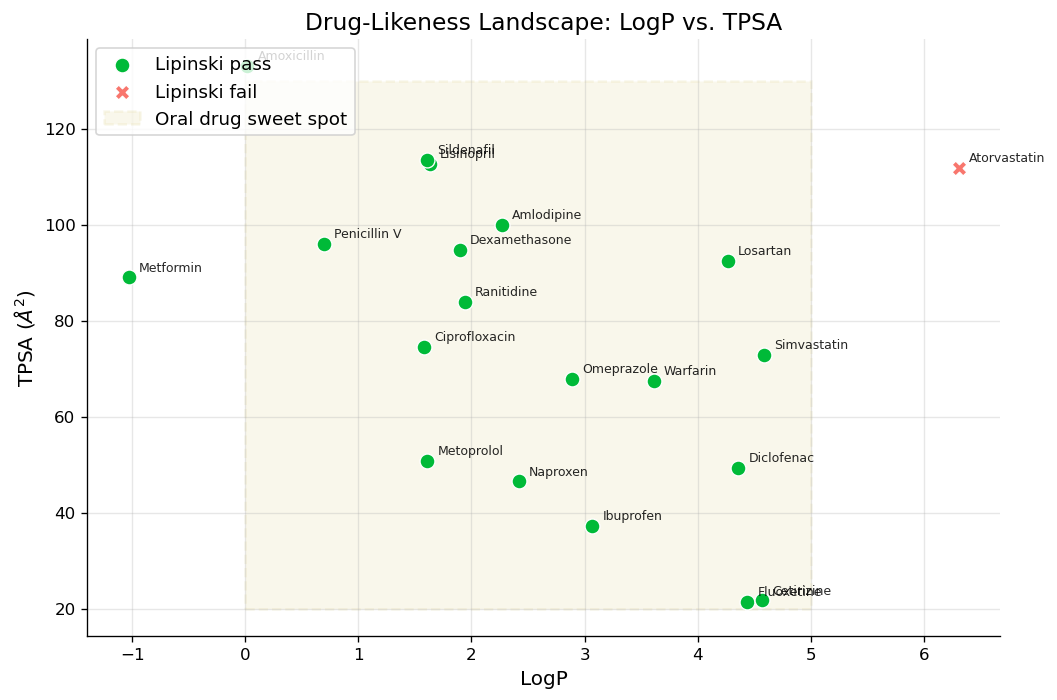

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

pass_mask = mol_df["Lipinski_Pass"]

# Plot passing and failing molecules
ax.scatter(
    mol_df.loc[pass_mask, "LogP"],
    mol_df.loc[pass_mask, "TPSA"],
    color=EMERALD,
    s=80,
    edgecolors="white",
    linewidth=0.8,
    label="Lipinski pass",
    zorder=3,
)
ax.scatter(
    mol_df.loc[~pass_mask, "LogP"],
    mol_df.loc[~pass_mask, "TPSA"],
    color=SALMON,
    s=80,
    edgecolors="white",
    linewidth=0.8,
    marker="X",
    label="Lipinski fail",
    zorder=3,
)

# Label each point
for name, row in mol_df.iterrows():
    ax.annotate(
        name,
        (row["LogP"], row["TPSA"]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=7.5,
        alpha=0.85,
    )

# Draw Lipinski guideline region
from matplotlib.patches import Rectangle

rect = Rectangle(
    (0, 20),
    5,
    110,
    linewidth=1.5,
    edgecolor=GOLD,
    facecolor=GOLD,
    alpha=0.08,
    linestyle="--",
    label="Oral drug sweet spot",
)
ax.add_patch(rect)

ax.set_xlabel("LogP")
ax.set_ylabel("TPSA ($\\AA^2$)")
ax.set_title("Drug-Likeness Landscape: LogP vs. TPSA")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

---

## Key Takeaways

- **SMILES** is a compact text encoding of molecular graphs. It handles atoms, bonds, branches, rings, aromaticity, and stereochemistry in a single ASCII string.
- **RDKit** is the standard open-source cheminformatics toolkit. Its core operations — parsing (`MolFromSmiles`), canonicalisation (`MolToSmiles`), drawing (`MolToImage`), and descriptor computation — form the foundation of any molecular data pipeline.
- **Molecular descriptors** (MW, LogP, HBD, HBA, TPSA, rotatable bonds) convert molecules into numerical features suitable for statistical analysis. **Lipinski's Rule of Five** is a simple, empirically derived heuristic for drug-likeness.
- **Morgan fingerprints** encode substructural features into fixed-length bit vectors. The **Tanimoto coefficient** measures the overlap between two fingerprints and quantifies molecular similarity.
- **Molecular editing** in RDKit enables programmatic exploration of structure-activity relationships — the same transformations that medicinal chemists perform at the bench.
- Combining SMILES parsing, descriptor computation, and pandas DataFrames creates a **molecular dataset** ready for the regression and classification models introduced in the following notebooks.

## Further Reading

- Weininger, D. (1988). "SMILES, a Chemical Language and Information System." *Journal of Chemical Information and Computer Sciences*, 28(1), 31-36.
- Lipinski, C. A. et al. (1997). "Experimental and computational approaches to estimate solubility and permeability in drug discovery and development settings." *Advanced Drug Delivery Reviews*, 23(1-3), 3-25.
- Rogers, D. & Hahn, M. (2010). "Extended-Connectivity Fingerprints." *Journal of Chemical Information and Modeling*, 50(5), 742-754.
- RDKit Documentation: https://www.rdkit.org/docs/

In [15]:
cfg.save_gifs(clean=True)

  No new GIFs to save.
